<a href="https://colab.research.google.com/github/elwaa27/prediksi-konsumsi-energi-sdg7/blob/main/prediksi_konsumsi_energi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving household_power_consumption - Copy.csv to household_power_consumption - Copy.csv


In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("household_power_consumption - Copy.csv")

In [5]:
df.head()

,time,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
0,00:00:00,2.580,0.136,241.97,10.6,0.0,0.0,0.0
1,00:01:00,2.552,0.100,241.75,10.4,0.0,0.0,0.0
2,00:02:00,2.550,0.100,241.64,10.4,0.0,0.0,0.0
3,00:03:00,2.550,0.100,241.71,10.4,0.0,0.0,0.0
4,00:04:00,2.554,0.100,241.98,10.4,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   time                   260640 non-null  object 
 1   global_active_power    256869 non-null  float64
 2   global_reactive_power  256869 non-null  float64
 3   voltage                256869 non-null  float64
 4   global_intensity       256869 non-null  float64
 5   sub_metering_1         256869 non-null  float64
 6   sub_metering_2         256869 non-null  float64
 7   sub_metering_3         256869 non-null  float64
dtypes: float64(7), object(1)
memory usage: 15.9+ MB


In [7]:
df.shape

(260640, 8)

In [8]:
df.isnull().sum()

,0
time,0
global_active_power,3771
global_reactive_power,3771
voltage,3771
global_intensity,3771
sub_metering_1,3771
sub_metering_2,3771
sub_metering_3,3771


In [9]:
df.duplicated().sum()

np.int64(2356)

In [10]:
# Menghapus data duplikat
df = df.drop_duplicates()

# Menghapus data yang memiliki nilai kosong
df = df.dropna()

# Melihat ukuran data setelah dibersihkan
df.shape

(256844, 8)

In [11]:
# Mengecek kembali data kosong
df.isnull().sum()

,0
time,0
global_active_power,0
global_reactive_power,0
voltage,0
global_intensity,0
sub_metering_1,0
sub_metering_2,0
sub_metering_3,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
count,256844.000000,256844.000000,256844.000000,256844.000000,256844.000000,256844.000000,256844.000000
mean,1.165029,0.123740,239.208773,4.975153,1.332610,1.670773,5.832392
std,1.181853,0.111871,3.592846,4.999574,6.705284,6.631664,8.186905
min,0.082000,0.000000,223.490000,0.400000,0.000000,0.000000,0.000000
25%,0.296000,0.000000,236.650000,1.400000,0.000000,0.000000,0.000000
50%,0.564000,0.104000,239.610000,2.600000,0.000000,0.000000,0.000000
75%,1.606000,0.194000,241.810000,6.800000,0.000000,1.000000,17.000000
max,10.670000,1.148000,250.890000,46.400000,78.000000,78.000000,20.000000


In [14]:
df['time'].head(10)

,time
0,00:00:00
1,00:01:00
2,00:02:00
3,00:03:00
4,00:04:00
5,00:05:00
6,00:06:00
7,00:07:00
8,00:08:00
9,00:09:00


In [15]:
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')

df['time'].head()

,time
0,1900-01-01 00:00:00
1,1900-01-01 00:01:00
2,1900-01-01 00:02:00
3,1900-01-01 00:03:00
4,1900-01-01 00:04:00


In [16]:
# Membuat kategori konsumsi energi

df['energy_category'] = pd.cut(
    df['global_active_power'],
    bins=[0, 0.296, 1.606, float('inf')],
    labels=['Rendah', 'Sedang', 'Tinggi']
)

# Melihat hasil kategori
df[['global_active_power', 'energy_category']].head(10)

,global_active_power,energy_category
0,2.580,Tinggi
1,2.552,Tinggi
2,2.550,Tinggi
3,2.550,Tinggi
4,2.554,Tinggi
5,2.550,Tinggi
6,2.534,Tinggi
7,2.484,Tinggi
8,2.468,Tinggi
9,2.486,Tinggi


In [17]:
df['energy_category'].value_counts()

,count
energy_category,
Sedang,128118
Rendah,64575
Tinggi,64151


In [18]:
X = df[
    [
        'global_reactive_power',
        'voltage',
        'global_intensity',
        'sub_metering_1',
        'sub_metering_2',
        'sub_metering_3'
    ]
]

y = df['energy_category']

print("Jumlah data X:", X.shape)
print("Jumlah data y:", y.shape)

Jumlah data X: (256844, 6)
Jumlah data y: (256844,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (205475, 6)
Data testing : (51369, 6)


In [20]:
from sklearn.tree import DecisionTreeClassifier

# Membuat model Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Melatih model menggunakan data training
dt_model.fit(X_train, y_train)

print("Decision Tree berhasil dilatih")

Decision Tree berhasil dilatih


In [21]:
# Melakukan prediksi pada data testing
y_pred_dt = dt_model.predict(X_test)

# Menampilkan 10 hasil prediksi pertama
print(y_pred_dt[:10])

['Sedang' 'Tinggi' 'Sedang' 'Tinggi' 'Tinggi' 'Rendah' 'Tinggi' 'Sedang'
 'Sedang' 'Sedang']


In [22]:
from sklearn.metrics import accuracy_score

akurasi_dt = accuracy_score(y_test, y_pred_dt)

print("Akurasi Decision Tree:", akurasi_dt)
print("Akurasi Decision Tree (%):", akurasi_dt * 100)

Akurasi Decision Tree: 0.9631100469154549
Akurasi Decision Tree (%): 96.31100469154549


In [23]:
from sklearn.ensemble import RandomForestClassifier

# Membuat model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Melatih model menggunakan data training
rf_model.fit(X_train, y_train)

print("Random Forest berhasil dilatih")

Random Forest berhasil dilatih


In [24]:
# Melakukan prediksi menggunakan Random Forest
y_pred_rf = rf_model.predict(X_test)

# Menampilkan 10 hasil prediksi pertama
print(y_pred_rf[:10])

['Sedang' 'Tinggi' 'Sedang' 'Tinggi' 'Tinggi' 'Rendah' 'Tinggi' 'Sedang'
 'Sedang' 'Sedang']


In [25]:
from sklearn.metrics import accuracy_score

akurasi_rf = accuracy_score(y_test, y_pred_rf)

print("Akurasi Random Forest:", akurasi_rf)
print("Akurasi Random Forest (%):", akurasi_rf * 100)

Akurasi Random Forest: 0.9681130642994802
Akurasi Random Forest (%): 96.81130642994802


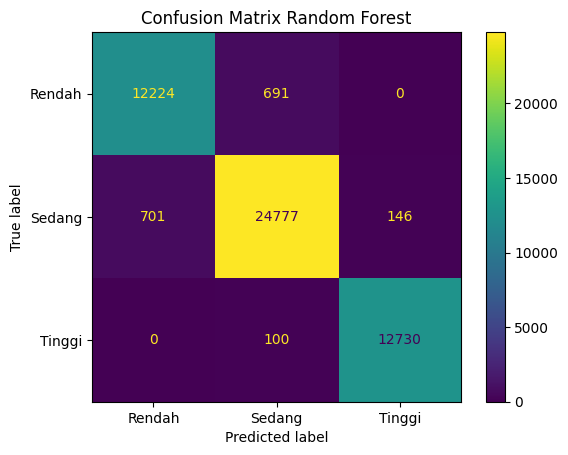

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Rendah', 'Sedang', 'Tinggi']
)

disp.plot()
plt.title("Confusion Matrix Random Forest")
plt.show()

In [27]:
from sklearn.metrics import confusion_matrix

# Menghitung Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix Random Forest:")
print(cm_rf)

Confusion Matrix Random Forest:
[[12224   691     0]
 [  701 24777   146]
 [    0   100 12730]]


In [28]:
from sklearn.metrics import confusion_matrix

# Menghitung Confusion Matrix Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix Decision Tree:")
print(cm_dt)

Confusion Matrix Decision Tree:
[[12191   724     0]
 [  859 24609   156]
 [    0   156 12674]]


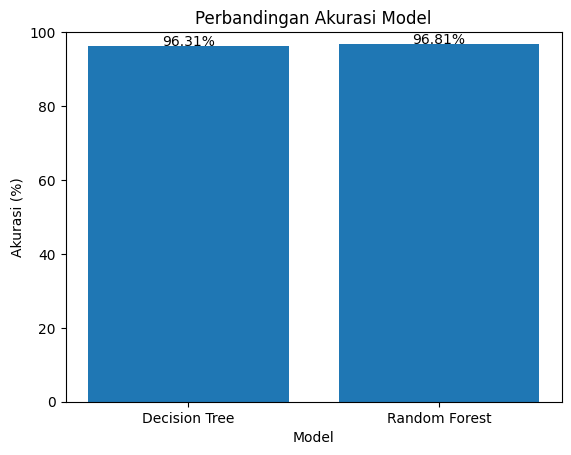

In [29]:
import matplotlib.pyplot as plt

# Data akurasi
model = ['Decision Tree', 'Random Forest']
akurasi = [akurasi_dt * 100, akurasi_rf * 100]

# Membuat grafik
plt.bar(model, akurasi)

plt.title('Perbandingan Akurasi Model')
plt.xlabel('Model')
plt.ylabel('Akurasi (%)')

# Menampilkan nilai di atas batang
for i, nilai in enumerate(akurasi):
    plt.text(i, nilai + 0.1, f'{nilai:.2f}%', ha='center')

plt.ylim(0, 100)
plt.show()

In [30]:
from sklearn.metrics import classification_report

print("Classification Report Random Forest:")
print(classification_report(y_test, y_pred_rf))

Classification Report Random Forest:
              precision    recall  f1-score   support

      Rendah       0.95      0.95      0.95     12915
      Sedang       0.97      0.97      0.97     25624
      Tinggi       0.99      0.99      0.99     12830

    accuracy                           0.97     51369
   macro avg       0.97      0.97      0.97     51369
weighted avg       0.97      0.97      0.97     51369



In [31]:
from sklearn.metrics import classification_report

print("Classification Report Decision Tree:")
print(classification_report(y_test, y_pred_dt))

Classification Report Decision Tree:
              precision    recall  f1-score   support

      Rendah       0.93      0.94      0.94     12915
      Sedang       0.97      0.96      0.96     25624
      Tinggi       0.99      0.99      0.99     12830

    accuracy                           0.96     51369
   macro avg       0.96      0.96      0.96     51369
weighted avg       0.96      0.96      0.96     51369



In [32]:
import pandas as pd

# Membuat tabel perbandingan model
hasil_model = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [akurasi_dt, akurasi_rf],
    'Accuracy (%)': [akurasi_dt * 100, akurasi_rf * 100]
})

hasil_model

,Model,Accuracy,Accuracy (%)
0,Decision Tree,0.963110,96.311005
1,Random Forest,0.968113,96.811306


In [34]:
# Membuat data baru dengan nama kolom yang sama seperti data training
data_baru = pd.DataFrame([[
    0.10,   # global_reactive_power
    240.00, # voltage
    2.50,   # global_intensity
    0.00,   # sub_metering_1
    1.00,   # sub_metering_2
    10.00   # sub_metering_3
]], columns=X.columns)

# Prediksi menggunakan Decision Tree
prediksi_dt = dt_model.predict(data_baru)

# Prediksi menggunakan Random Forest
prediksi_rf = rf_model.predict(data_baru)

print("Prediksi Decision Tree :", prediksi_dt[0])
print("Prediksi Random Forest :", prediksi_rf[0])

Prediksi Decision Tree : Sedang
Prediksi Random Forest : Sedang
